<a href="https://colab.research.google.com/github/YuriFla94/Processamento-de-Sinais-1/blob/main/Taref3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  1. Análise da Resposta em Frequência e Diagrama de Polos e Zeros de $H(z)$

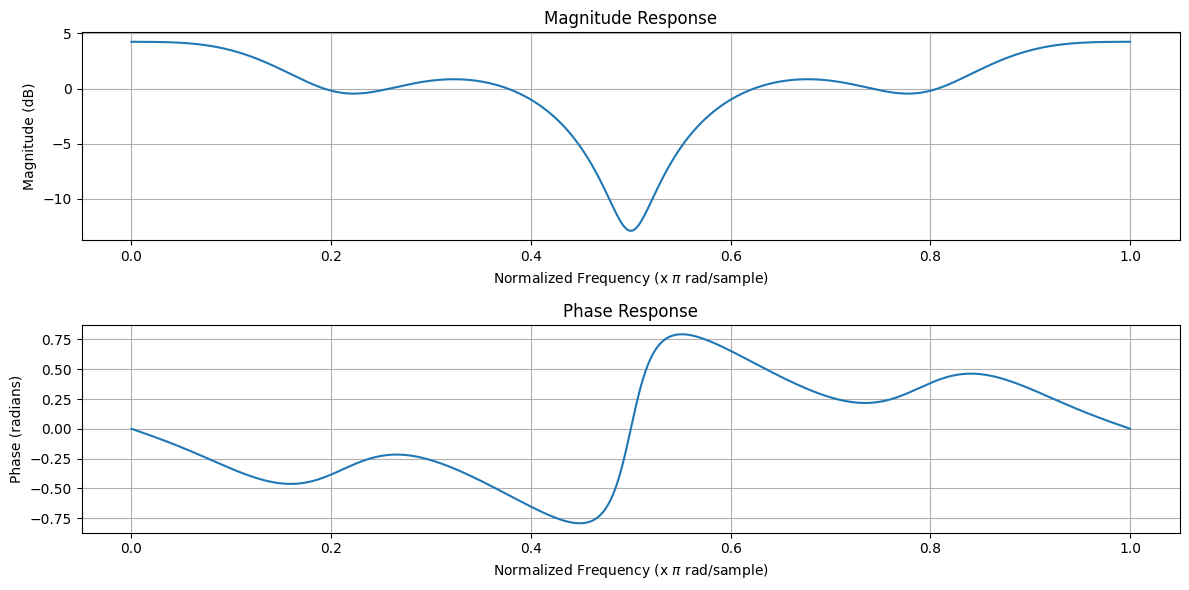

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define the coefficients of the numerator polynomial (b)
# H(z) = 1 + 0.49z^-2 + 0.2401z^-6 - 0.0576z^-8 - 0.0282z^-10 - 0.0138z^-12
# The coefficients correspond to powers of z^-k. Missing powers have a coefficient of 0.
b = np.array([1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138])

# The denominator is 1, so the coefficients of the denominator polynomial (a) are just [1]
a = np.array([1])

# Calculate the frequency response
# N = 8192 is chosen to get a smooth frequency response plot.
w, h = signal.freqz(b, a, worN=8192)

# Convert angular frequency w to Hz (assuming sampling frequency Fs=1, so w covers 0 to pi)
# If Fs is known, we can multiply w by Fs/(2*pi)

# Plot the magnitude response
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(w / np.pi, 20 * np.log10(abs(h)))
plt.title('Magnitude Response')
plt.xlabel(r'Normalized Frequency (x $\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Plot the phase response
plt.subplot(2, 1, 2)
plt.plot(w / np.pi, np.unwrap(np.angle(h)))
plt.title('Phase Response')
plt.xlabel(r'Normalized Frequency (x $\pi$ rad/sample)')
plt.ylabel('Phase (radians)')
plt.grid(True)
plt.tight_layout()
plt.show()

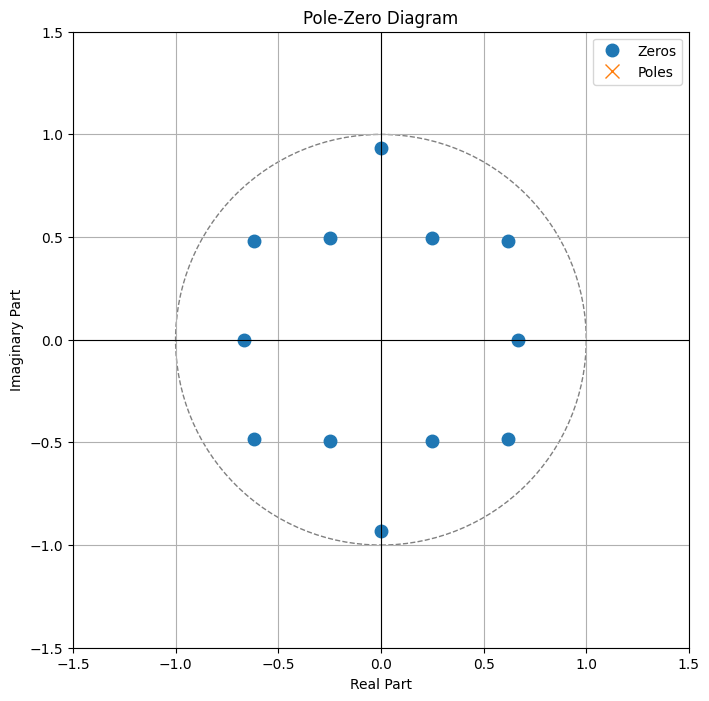

In [ ]:
# Calculate poles and zeros
# The roots of the numerator polynomial are the zeros.
# The roots of the denominator polynomial are the poles.

zeros = np.roots(b)
poles = np.roots(a)

# Create the pole-zero plot
plt.figure(figsize=(8, 8))
plt.plot(np.real(zeros), np.imag(zeros), 'o', markersize=9, label='Zeros')
plt.plot(np.real(poles), np.imag(poles), 'x', markersize=10, label='Poles')

# Draw the unit circle
unit_circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(unit_circle)

plt.title('Pole-Zero Diagram')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.grid(True)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

### 2. Resposta do Sistema ao Sinal de Áudio (handel.wav) e Análise Espectral

In [ ]:
from scipy.io import wavfile

# Read the audio file
# The sampling rate Fs is in samples per second, and data is the audio signal samples.
Fs, data = wavfile.read('/content/handel.wav')

# If the audio is stereo, take only one channel (e.g., the first one)
if data.ndim > 1:
    data = data[:, 0]

print(f"Sampling rate (Fs): {Fs} Hz")
print(f"Number of samples: {len(data)}")
print(f"Audio data type: {data.dtype}")

Sampling rate (Fs): 8192 Hz
Number of samples: 73113
Audio data type: int16


In [ ]:
# Apply the filter H(z) to the audio signal
# b and a are the filter coefficients defined in the previous cells.
filtered_data = signal.lfilter(b, a, data)

print("Filtragem do sinal de áudio concluída.")

Filtragem do sinal de áudio concluída.


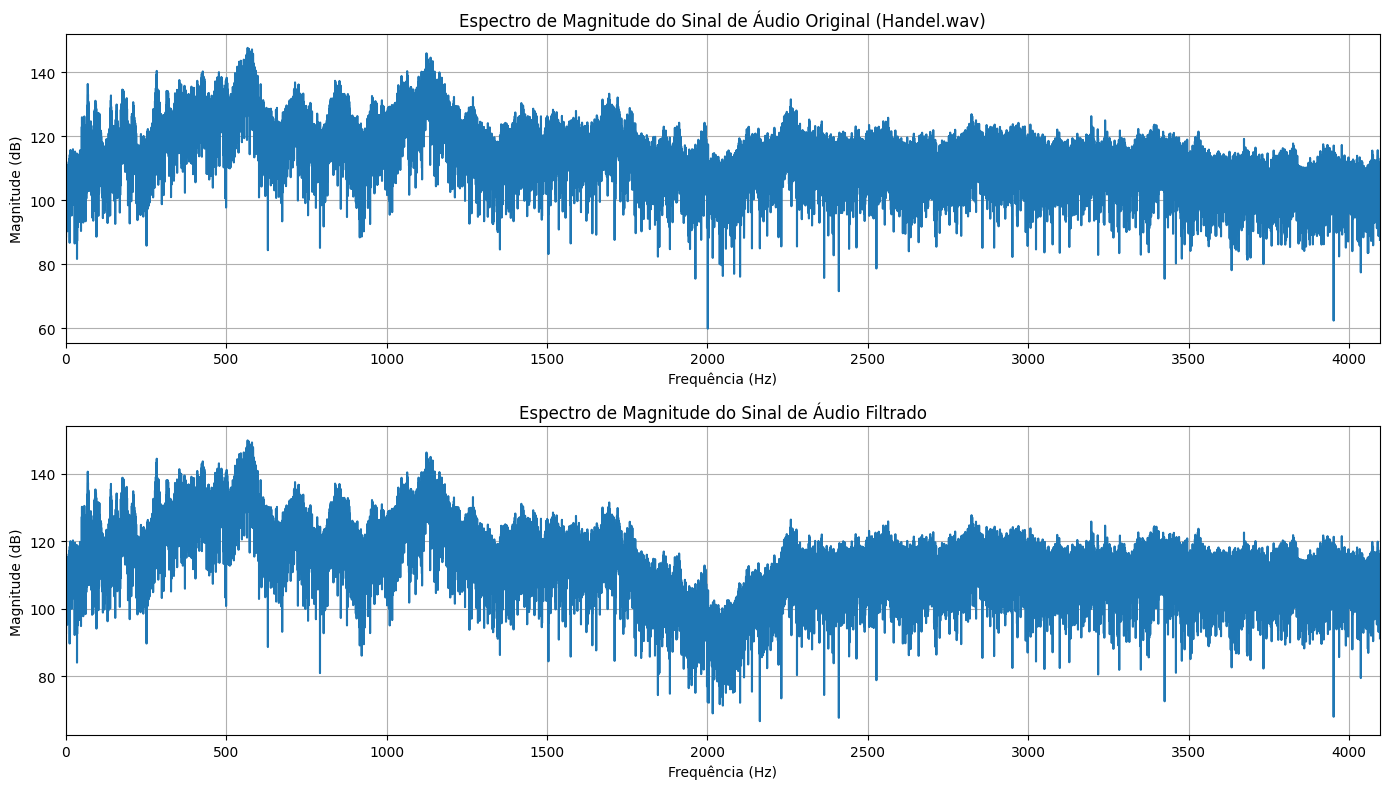

In [ ]:
from scipy.fft import fft, fftfreq

# Calculate the Fast Fourier Transform (FFT) for both original and filtered signals
N = len(data)  # Number of samples

# Original signal spectrum
xf = fftfreq(N, 1 / Fs)
yf_original = fft(data)

# Filtered signal spectrum
yf_filtered = fft(filtered_data)

# Plot the magnitude spectrum (only positive frequencies)
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(xf[:N//2], 20 * np.log10(np.abs(yf_original[:N//2])))
plt.title('Espectro de Magnitude do Sinal de Áudio Original (Handel.wav)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.xlim(0, Fs/2)

plt.subplot(2, 1, 2)
plt.plot(xf[:N//2], 20 * np.log10(np.abs(yf_filtered[:N//2])))
plt.title('Espectro de Magnitude do Sinal de Áudio Filtrado')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.xlim(0, Fs/2)

plt.tight_layout()
plt.show()

#### Análise dos Resultados do Espectro:

Observando os gráficos de espectro de magnitude do sinal de áudio original e filtrado, podemos tirar as seguintes conclusões:

1.  **Sinal Original (`handel.wav`)**: O espectro do sinal original mostra a distribuição de energia nas diferentes frequências presentes na gravação de áudio. É de se esperar que um sinal de áudio tenha componentes em diversas frequências, que correspondem aos sons, vozes, instrumentos, etc. A forma do espectro original serve como base para comparar o efeito do filtro.

2.  **Sinal Filtrado**: O espectro do sinal após a aplicação do filtro H(z) deve refletir as características da resposta em frequência do filtro que foi plotada na célula inicial. Se o filtro é, por exemplo, um filtro passa-baixas, espera-se que as componentes de alta frequência sejam atenuadas no sinal filtrado, enquanto as baixas frequências sejam preservadas ou amplificadas, dependendo do ganho do filtro nessas regiões.

    *   **Comparação entre Original e Filtrado**: Ao comparar os dois espectros, podemos identificar claramente quais bandas de frequência foram mais afetadas pelo filtro. Áreas onde o espectro filtrado tem magnitude significativamente menor (ou maior) do que o original indicam atenuação (ou amplificação) por parte do filtro H(z).
    *   **Relação com H(z)**: A forma do espectro do sinal filtrado deve, em linhas gerais, seguir o padrão do módulo da resposta em frequência `|H(w)|` do filtro, que foi plotado na primeira célula. Picos e vales na resposta em frequência do filtro se manifestarão como atenuações ou amplificações correspondentes no espectro do sinal de áudio, alterando sua "coloração" sonora.

Em resumo, a análise espectral nos permite visualizar como o filtro H(z) modificou o conteúdo de frequência do sinal de áudio, confirmando as características de filtragem observadas na resposta em frequência do próprio filtro.

QUESTÃO 3

### 3. Projeto do Filtro Inverso e Recuperação do Sinal de Áudio

Para recuperar o sinal de áudio original, precisamos projetar um filtro inverso $H_{inv}(z)$ tal que $H_{inv}(z) = 1/H(z)$. Como $H(z) = b/a$, então $H_{inv}(z) = a/b$. Os coeficientes do numerador do filtro inverso serão `a`, e os coeficientes do denominador serão `b`.

In [ ]:
# Coeficientes do filtro inverso
b_inv = a  # Numerador do filtro inverso é o denominador do filtro original
a_inv = b  # Denominador do filtro inverso é o numerador do filtro original

print("Coeficientes do filtro inverso definidos.")

Coeficientes do filtro inverso definidos.


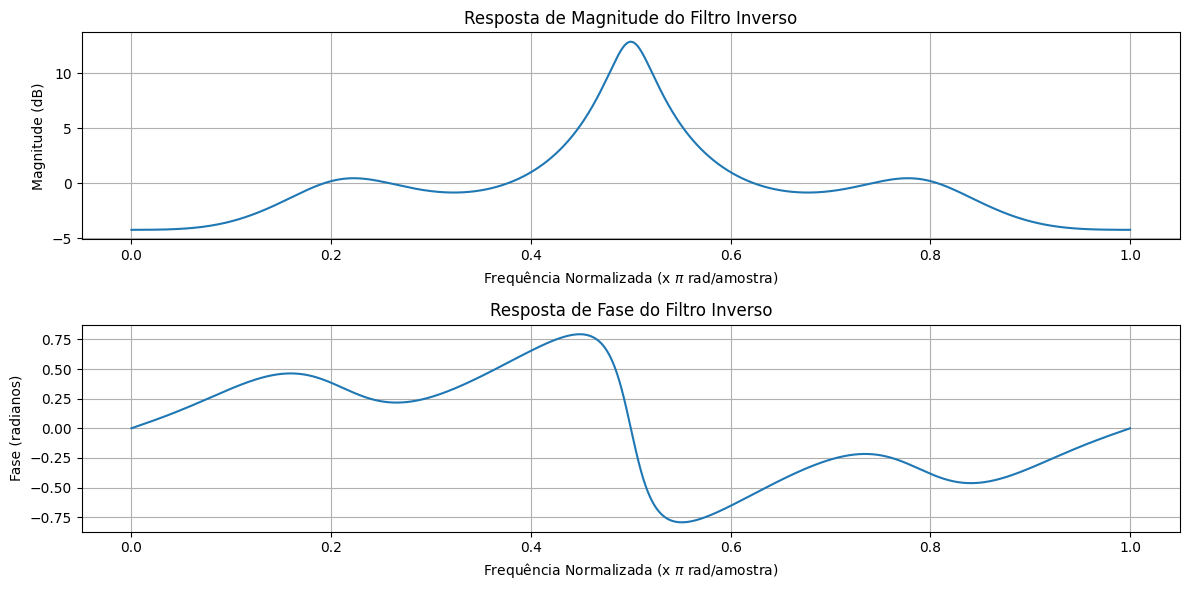

In [ ]:
# Calcular a resposta em frequência do filtro inverso
w_inv, h_inv = signal.freqz(b_inv, a_inv, worN=8192)

# Plotar a resposta de magnitude do filtro inverso
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(w_inv / np.pi, 20 * np.log10(abs(h_inv)))
plt.title('Resposta de Magnitude do Filtro Inverso')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

# Plotar a resposta de fase do filtro inverso
plt.subplot(2, 1, 2)
plt.plot(w_inv / np.pi, np.unwrap(np.angle(h_inv)))
plt.title('Resposta de Fase do Filtro Inverso')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
plt.ylabel('Fase (radianos)')
plt.grid(True)
plt.tight_layout()
plt.show()

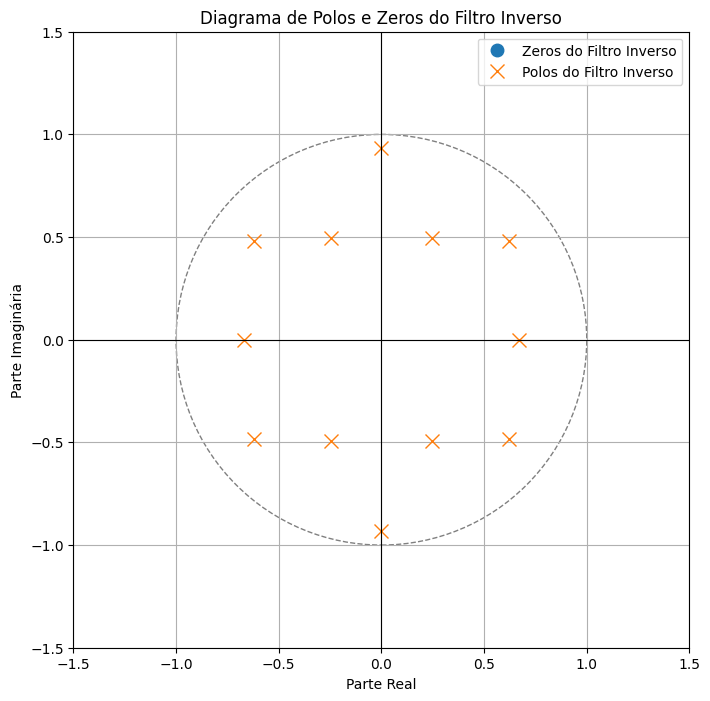

In [ ]:
# Calcular os polos e zeros do filtro inverso
# Zeros do filtro inverso são as raízes de b_inv (que é 'a')
# Polos do filtro inverso são as raízes de a_inv (que é 'b')

zeros_inv = np.roots(b_inv)
poles_inv = np.roots(a_inv)

# Criar o diagrama de polos e zeros para o filtro inverso
plt.figure(figsize=(8, 8))
plt.plot(np.real(zeros_inv), np.imag(zeros_inv), 'o', markersize=9, label='Zeros do Filtro Inverso')
plt.plot(np.real(poles_inv), np.imag(poles_inv), 'x', markersize=10, label='Polos do Filtro Inverso')

# Desenhar o círculo unitário
unit_circle_inv = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(unit_circle_inv)

plt.title('Diagrama de Polos e Zeros do Filtro Inverso')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginária')
plt.grid(True)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

#### Aplicação do Filtro Inverso e Avaliação da Recuperação

Agora vamos aplicar o filtro inverso ao sinal que já foi filtrado para tentar recuperar o sinal original. Em seguida, vamos avaliar a qualidade da recuperação visualmente e com métricas.

In [ ]:
# Aplicar o filtro inverso ao sinal filtrado
recovered_data = signal.lfilter(b_inv, a_inv, filtered_data)

# Como o sinal original 'data' é int16 e 'recovered_data' é float, vamos convertê-lo para a mesma escala e tipo para comparação.
# Além disso, o lfilter pode introduzir um atraso, mas para este tipo de filtro FIR, o atraso é geralmente desprezível ou zero.
# Para comparar, é bom garantir que ambos tenham o mesmo tipo de dado e escala, se necessário.

# Normalizar o sinal recuperado para o mesmo tipo do original para uma comparação justa (opcional, dependendo da avaliação)
# Para uma avaliação mais direta, vamos converter 'recovered_data' para int16 e cortar valores se necessário.
# Multiplicamos pela amplitude máxima do tipo original (int16) antes de converter.
# Note: This direct conversion might introduce clipping if values exceed int16 range.
recovered_data_int16 = np.int16(np.clip(recovered_data, -32768, 32767))

print("Sinal de áudio recuperado.")

Sinal de áudio recuperado.


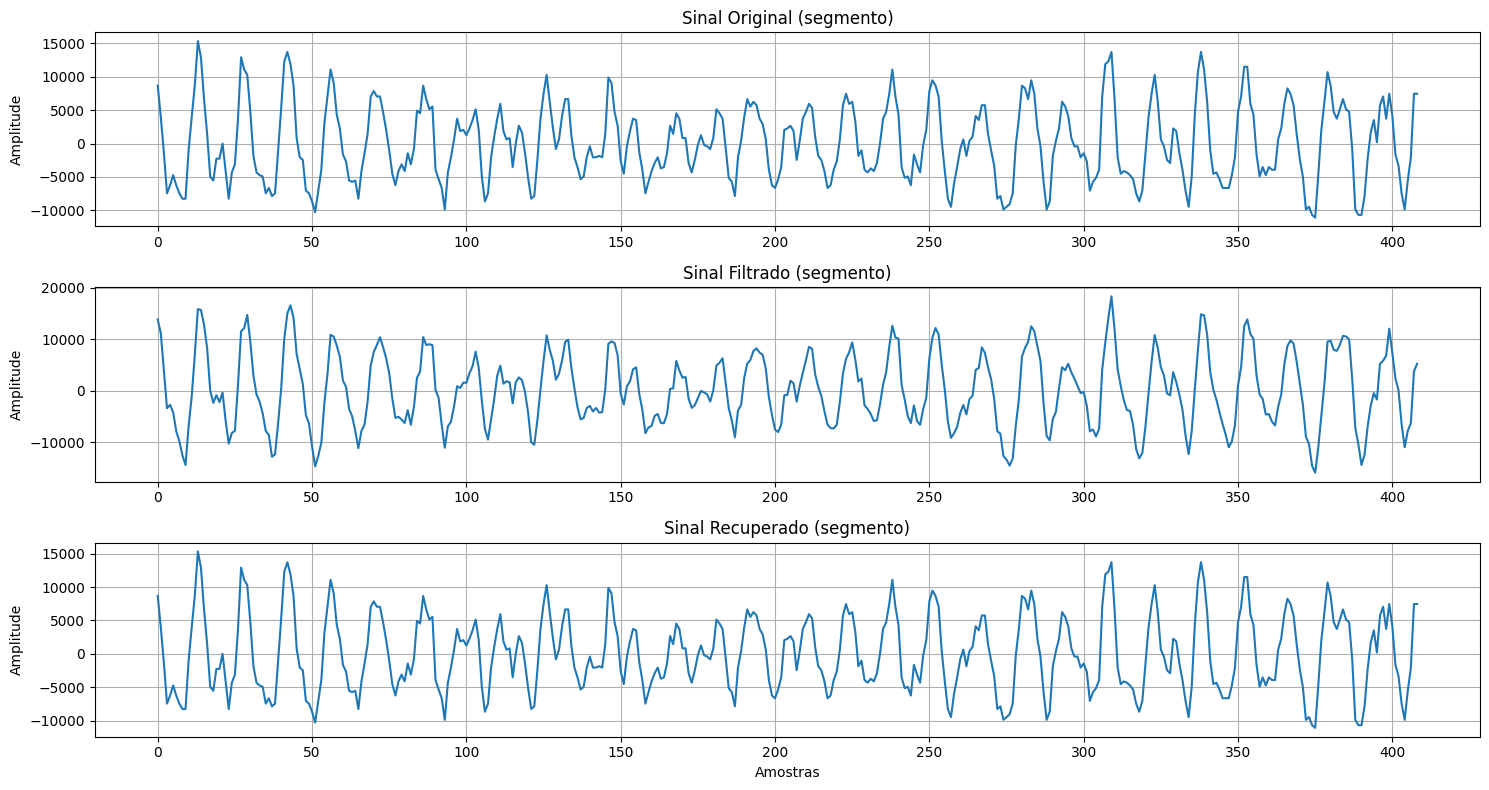

In [ ]:
# Visualização do sinal original, filtrado e recuperado
plt.figure(figsize=(15, 8))

start_sample = Fs * 1 # Começar em 1 segundo para evitar transientes iniciais
end_sample = int(Fs * 1.05) # Mostrar uma pequena seção de 0.05 segundos, convertendo para int

plt.subplot(3, 1, 1)
plt.plot(data[start_sample:end_sample])
plt.title('Sinal Original (segmento)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(filtered_data[start_sample:end_sample])
plt.title('Sinal Filtrado (segmento)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(recovered_data[start_sample:end_sample])
plt.title('Sinal Recuperado (segmento)')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# Calcular o erro entre o sinal original e o recuperado
# É importante que ambos os sinais tenham o mesmo comprimento para o cálculo.
# Usaremos 'data' e 'recovered_data'. Como 'lfilter' mantém o comprimento, está ok.

# Calcular MSE entre o sinal original e o recuperado
mse = mean_squared_error(data, recovered_data)
print(f"Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: {mse:.4f}")

# Calcular o Power da diferença (erro)
error_signal = data - recovered_data
power_error = np.mean(error_signal**2)

# Calcular o Power do sinal original, garantindo que os cálculos sejam feitos em float
power_original = np.mean(data.astype(float)**2)

# Calcular o Signal-to-Noise Ratio (SNR) se o erro for considerado 'ruído' de recuperação
# SNR = 10 * log10(Power_sinal / Power_erro)
if power_error > 0: # Avoid division by zero
    snr = 10 * np.log10(power_original / power_error)
    print(f"Relação Sinal-Ruído (SNR) do sinal recuperado em relação ao original: {snr:.2f} dB")
else:
    print("Power do erro é zero, indicando recuperação perfeita (ou erro insignificante). O SNR seria infinito.")

Erro Quadrático Médio (MSE) entre o sinal original e o recuperado: 0.0000
Relação Sinal-Ruído (SNR) do sinal recuperado em relação ao original: 323.41 dB


QUESTÃO 4

### 4. Análise da Nova Função de Transferência H(z) = (1 - z^-L) / (1 - a z^-L)

Vamos calcular a resposta em frequência e o diagrama de polos e zeros para a função de transferência dada, variando os parâmetros `a` e `L`.

Os coeficientes do numerador `b` e do denominador `a` para esta função de transferência são:
*   **Numerador**: $B(z) = 1 - z^{-L} \implies b = [1, 0, ..., 0, -1]$ (o $-1$ está na posição $L$)
*   **Denominador**: $A(z) = 1 - a z^{-L} \implies a = [1, 0, ..., 0, -a]$ (o $-a$ está na posição $L$)


--- Calculando para a = 0.7, L = 1 ---


/tmp/ipykernel_2915/3016293795.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w_new / np.pi, 20 * np.log10(abs(h_new)))


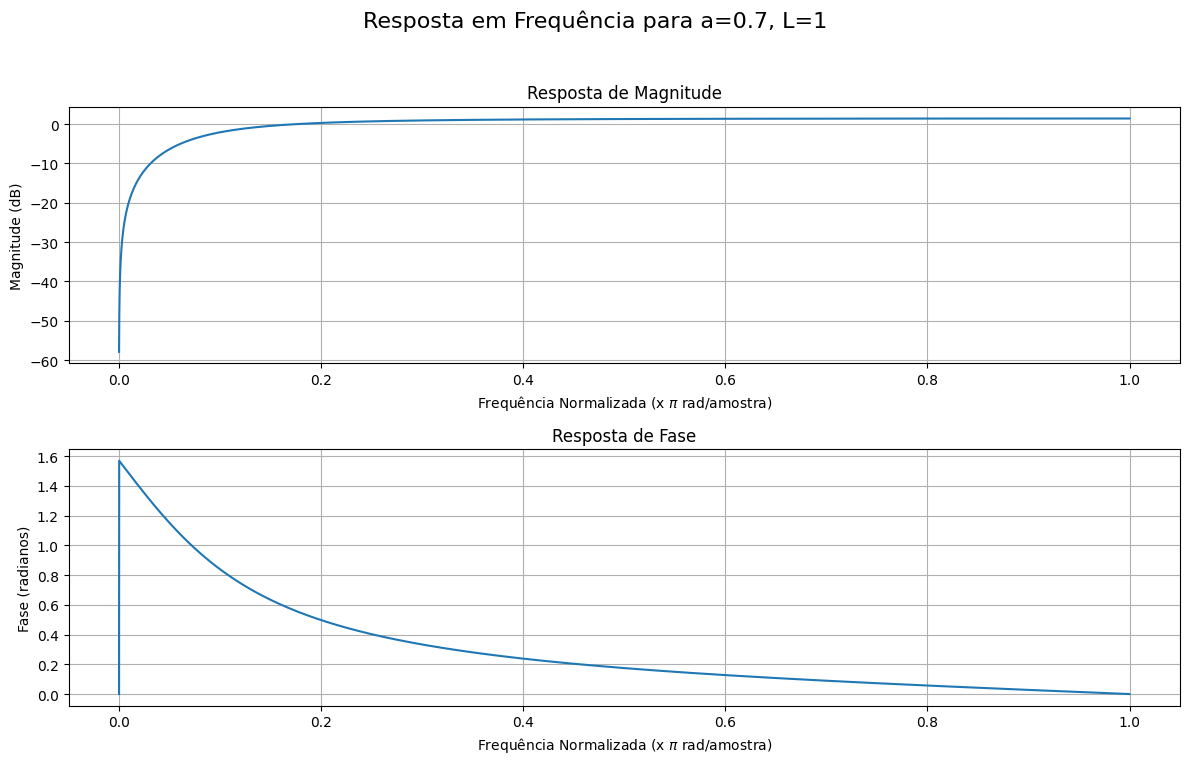

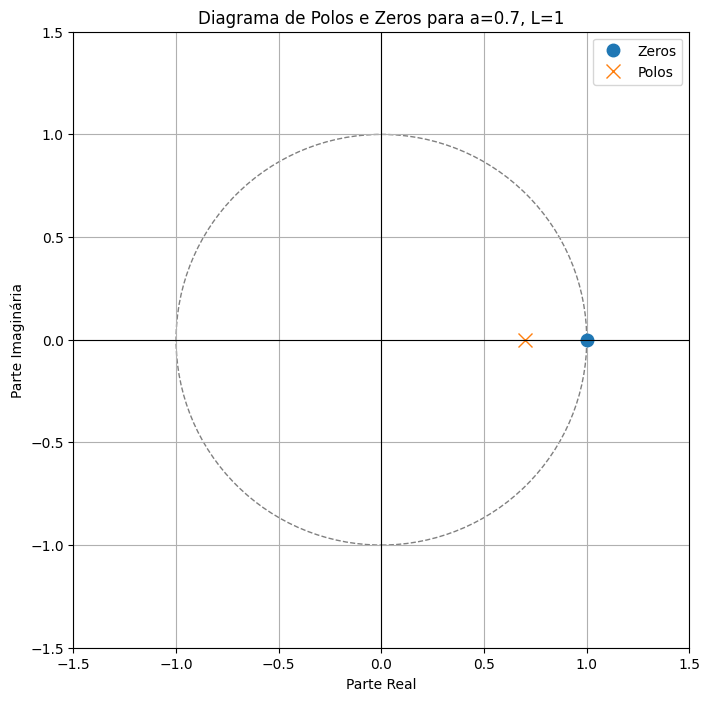

### Comentários para a=0.7, L=1:

A função de transferência H(z) = (1 - z^-1) / (1 - 0.7 z^-1) representa um filtro com características de filtro comb (pente) ou notch, dependendo dos parâmetros.

*   **Polo(s)**: O denominador $1 - 0.7 z^-1$ tem 1 polos. Para 0.7 < 1, todos os 1 polos estão no círculo de raio 0.7 no plano Z, distribuídos uniformemente. Como |0.7| < 1, o filtro é estável. A proximidade de 'a' com 1 (especialmente para a = 0.9) fará com que os picos na resposta em frequência sejam mais acentuados.\n
*   **Zero(s)**: O numerador $1 - z^-1$ tem 1 zeros que estão todos exatamente no círculo unitário (raio 1) no plano Z, distribuídos uniformemente. Estes zeros são as raízes L-ésimas da unidade.\n
*   **Resposta em Frequência**: Este filtro cria entalhes profundos (quase nulos, pois os zeros estão no círculo unitário) em frequências específicas, separadas por regiões de ganho. A posição desses entalhes e picos é determinada pelo valor de 1 e pela distribuição dos polos e zer

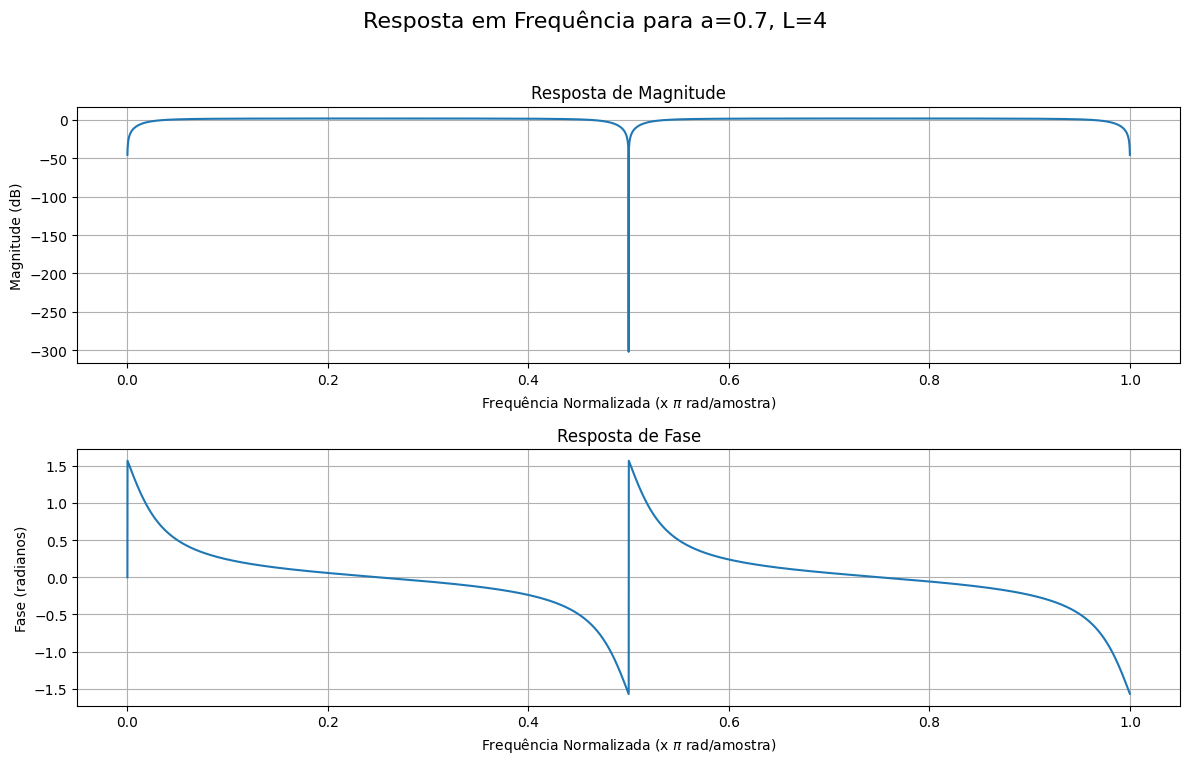

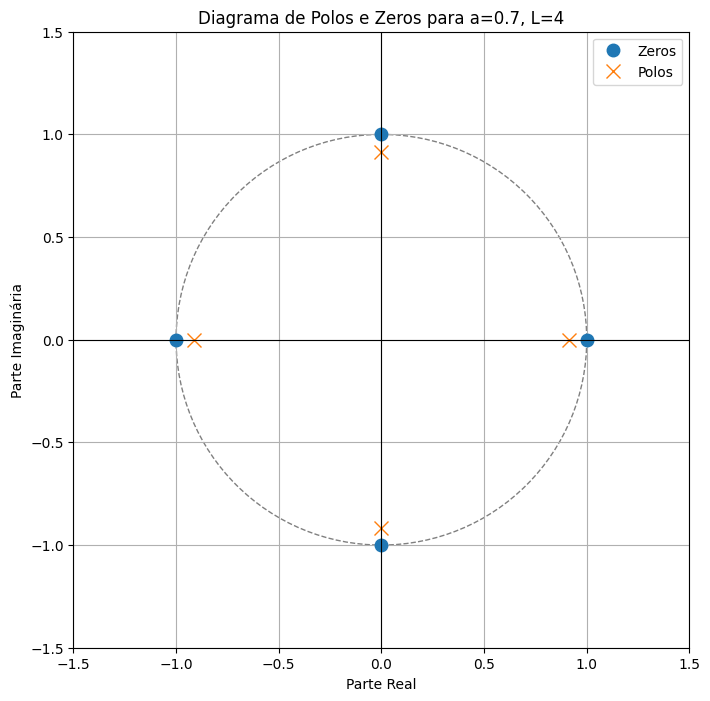

### Comentários para a=0.7, L=4:

A função de transferência H(z) = (1 - z^-4) / (1 - 0.7 z^-4) representa um filtro com características de filtro comb (pente) ou notch, dependendo dos parâmetros.

*   **Polo(s)**: O denominador $1 - 0.7 z^-4$ tem 4 polos. Para 0.7 < 1, todos os 4 polos estão no círculo de raio 0.7 no plano Z, distribuídos uniformemente. Como |0.7| < 1, o filtro é estável. A proximidade de 'a' com 1 (especialmente para a = 0.9) fará com que os picos na resposta em frequência sejam mais acentuados.\n
*   **Zero(s)**: O numerador $1 - z^-4$ tem 4 zeros que estão todos exatamente no círculo unitário (raio 1) no plano Z, distribuídos uniformemente. Estes zeros são as raízes L-ésimas da unidade.\n
*   **Resposta em Frequência**: Este filtro cria entalhes profundos (quase nulos, pois os zeros estão no círculo unitário) em frequências específicas, separadas por regiões de ganho. A posição desses entalhes e picos é determinada pelo valor de 4 e pela distribuição dos polos e zer

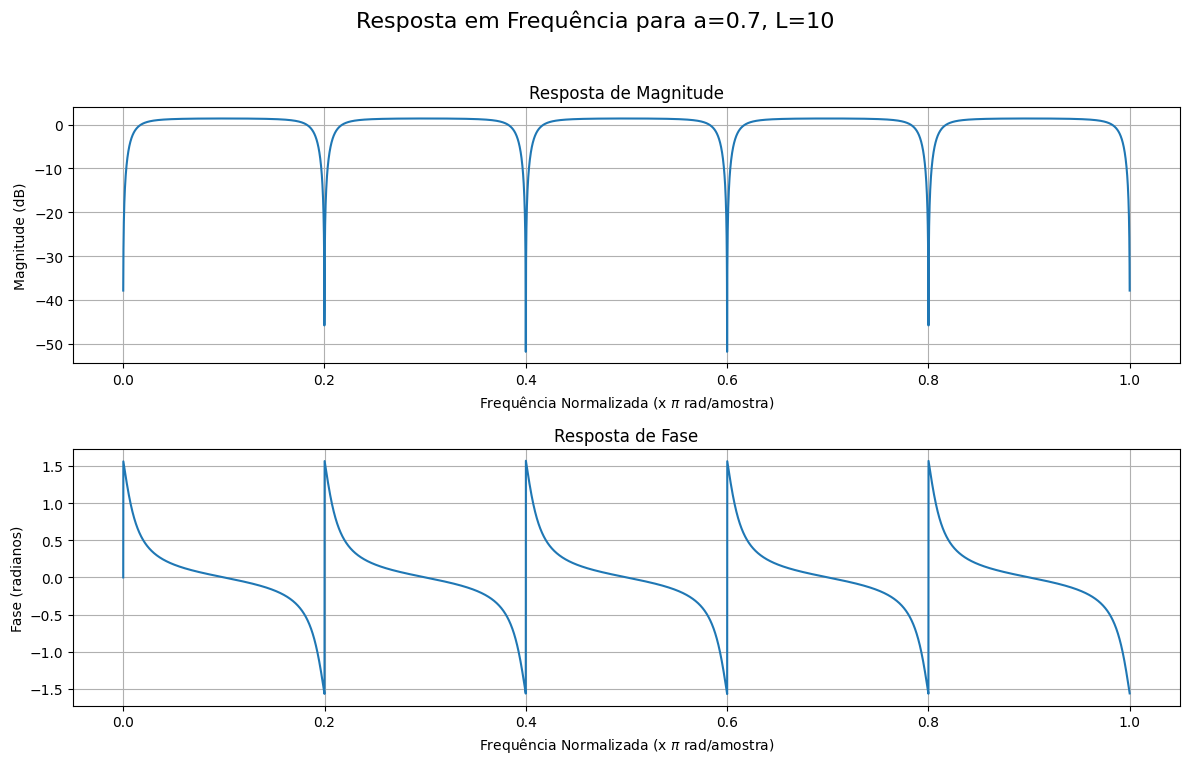

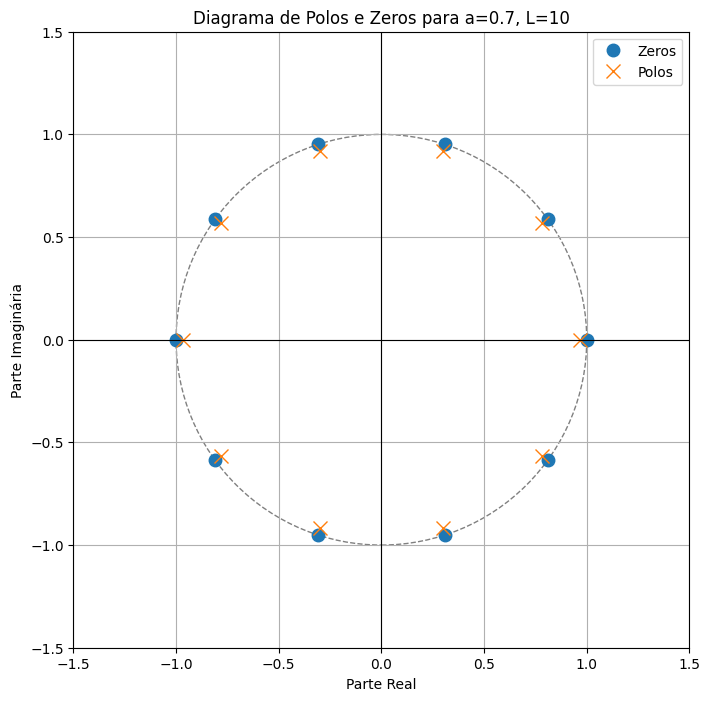

### Comentários para a=0.7, L=10:

A função de transferência H(z) = (1 - z^-10) / (1 - 0.7 z^-10) representa um filtro com características de filtro comb (pente) ou notch, dependendo dos parâmetros.

*   **Polo(s)**: O denominador $1 - 0.7 z^-10$ tem 10 polos. Para 0.7 < 1, todos os 10 polos estão no círculo de raio 0.7 no plano Z, distribuídos uniformemente. Como |0.7| < 1, o filtro é estável. A proximidade de 'a' com 1 (especialmente para a = 0.9) fará com que os picos na resposta em frequência sejam mais acentuados.\n
*   **Zero(s)**: O numerador $1 - z^-10$ tem 10 zeros que estão todos exatamente no círculo unitário (raio 1) no plano Z, distribuídos uniformemente. Estes zeros são as raízes L-ésimas da unidade.\n
*   **Resposta em Frequência**: Este filtro cria entalhes profundos (quase nulos, pois os zeros estão no círculo unitário) em frequências específicas, separadas por regiões de ganho. A posição desses entalhes e picos é determinada pelo valor de 10 e pela distribuição dos po

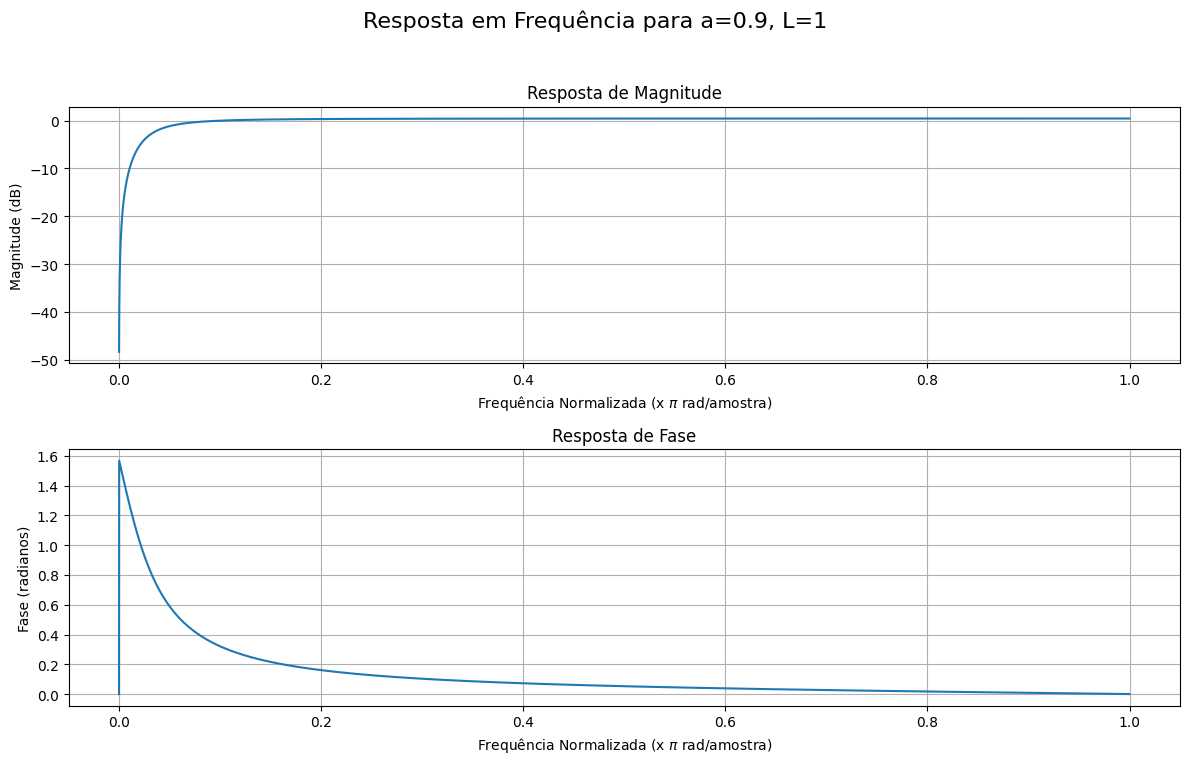

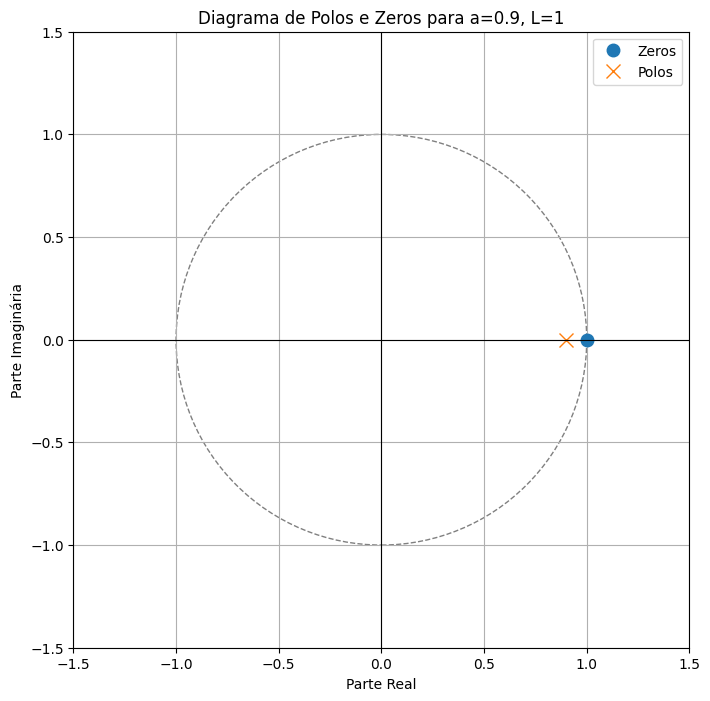

### Comentários para a=0.9, L=1:

A função de transferência H(z) = (1 - z^-1) / (1 - 0.9 z^-1) representa um filtro com características de filtro comb (pente) ou notch, dependendo dos parâmetros.

*   **Polo(s)**: O denominador $1 - 0.9 z^-1$ tem 1 polos. Para 0.9 < 1, todos os 1 polos estão no círculo de raio 0.9 no plano Z, distribuídos uniformemente. Como |0.9| < 1, o filtro é estável. A proximidade de 'a' com 1 (especialmente para a = 0.9) fará com que os picos na resposta em frequência sejam mais acentuados.\n
*   **Zero(s)**: O numerador $1 - z^-1$ tem 1 zeros que estão todos exatamente no círculo unitário (raio 1) no plano Z, distribuídos uniformemente. Estes zeros são as raízes L-ésimas da unidade.\n
*   **Resposta em Frequência**: Este filtro cria entalhes profundos (quase nulos, pois os zeros estão no círculo unitário) em frequências específicas, separadas por regiões de ganho. A posição desses entalhes e picos é determinada pelo valor de 1 e pela distribuição dos polos e zer

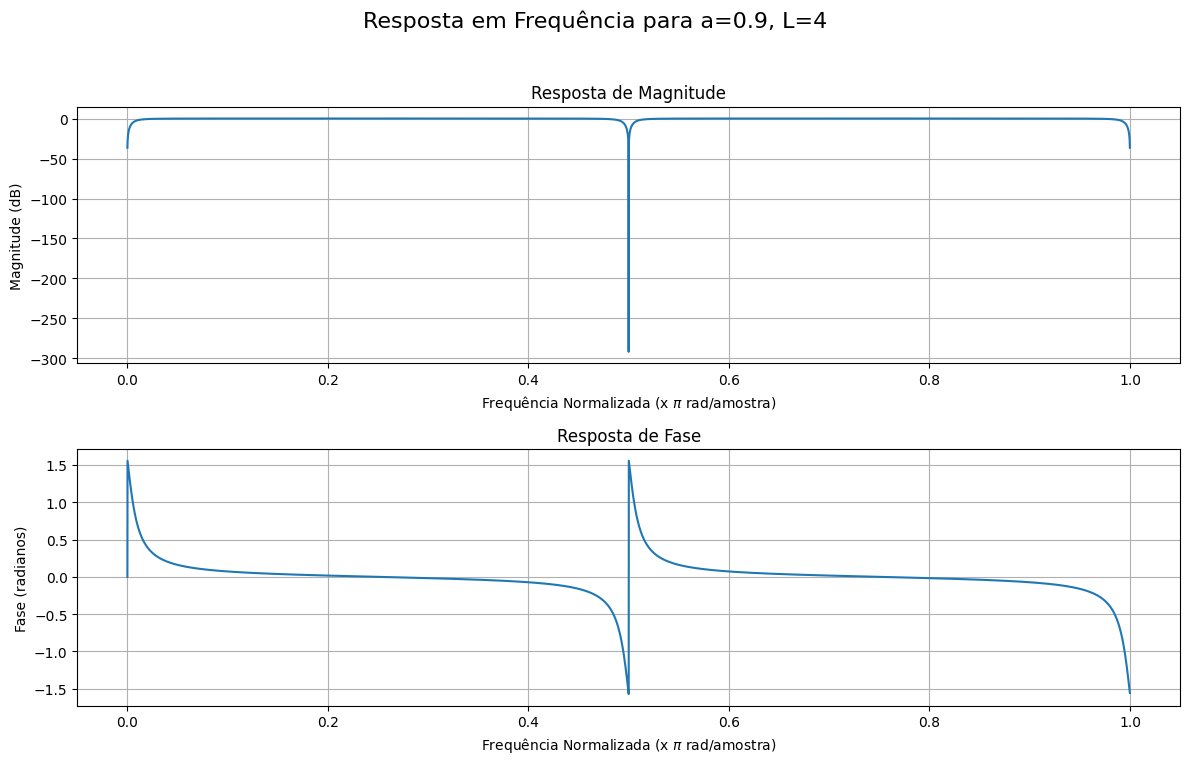

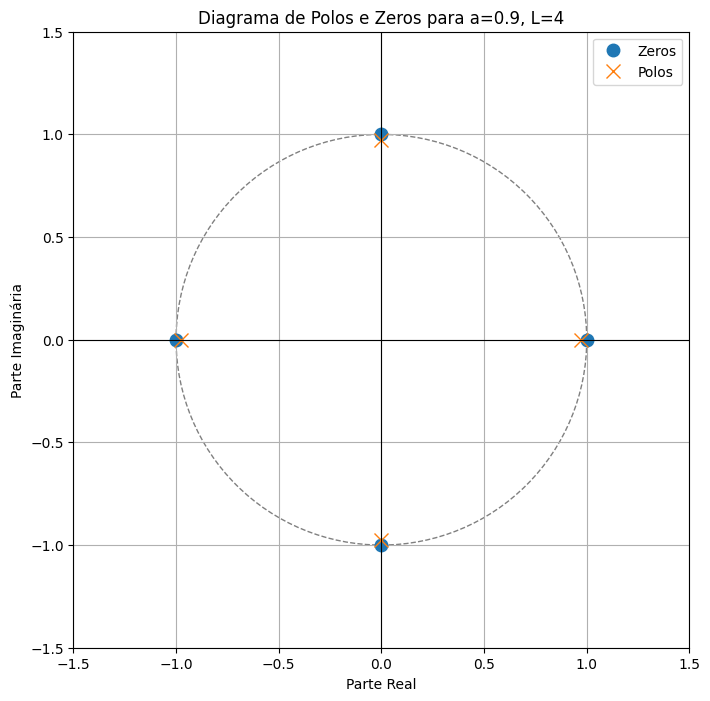

### Comentários para a=0.9, L=4:

A função de transferência H(z) = (1 - z^-4) / (1 - 0.9 z^-4) representa um filtro com características de filtro comb (pente) ou notch, dependendo dos parâmetros.

*   **Polo(s)**: O denominador $1 - 0.9 z^-4$ tem 4 polos. Para 0.9 < 1, todos os 4 polos estão no círculo de raio 0.9 no plano Z, distribuídos uniformemente. Como |0.9| < 1, o filtro é estável. A proximidade de 'a' com 1 (especialmente para a = 0.9) fará com que os picos na resposta em frequência sejam mais acentuados.\n
*   **Zero(s)**: O numerador $1 - z^-4$ tem 4 zeros que estão todos exatamente no círculo unitário (raio 1) no plano Z, distribuídos uniformemente. Estes zeros são as raízes L-ésimas da unidade.\n
*   **Resposta em Frequência**: Este filtro cria entalhes profundos (quase nulos, pois os zeros estão no círculo unitário) em frequências específicas, separadas por regiões de ganho. A posição desses entalhes e picos é determinada pelo valor de 4 e pela distribuição dos polos e zer

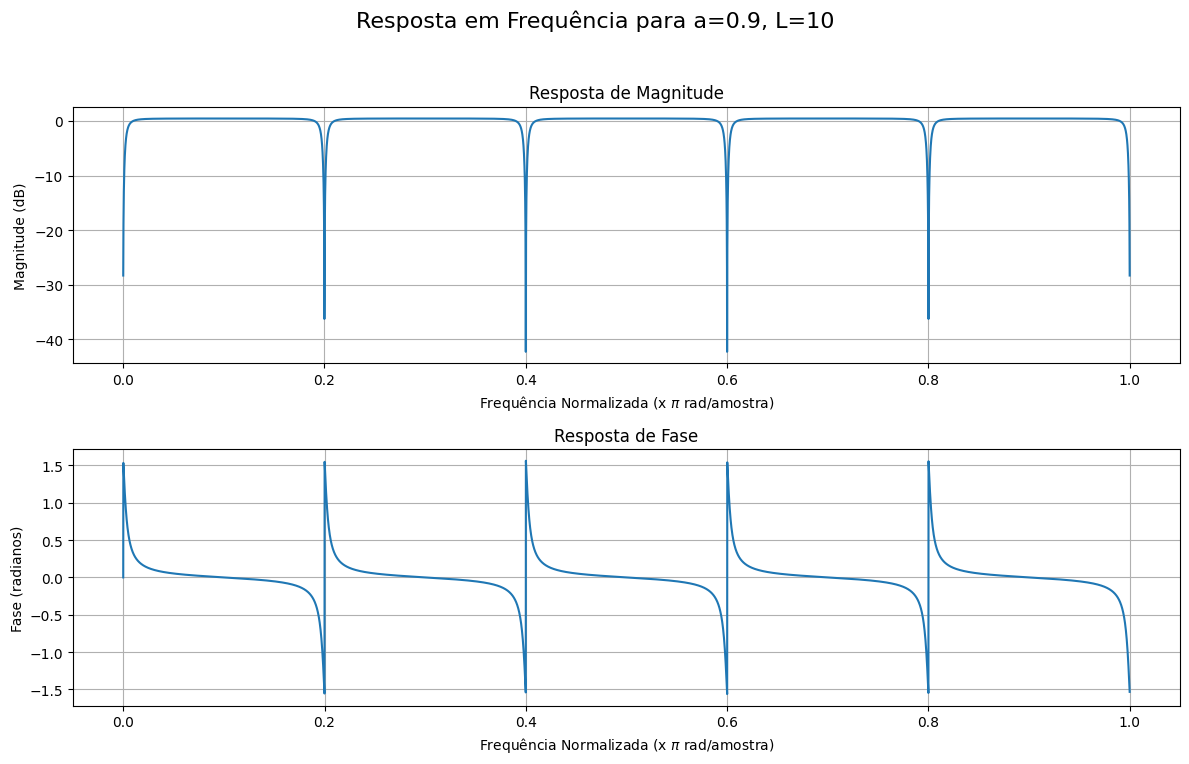

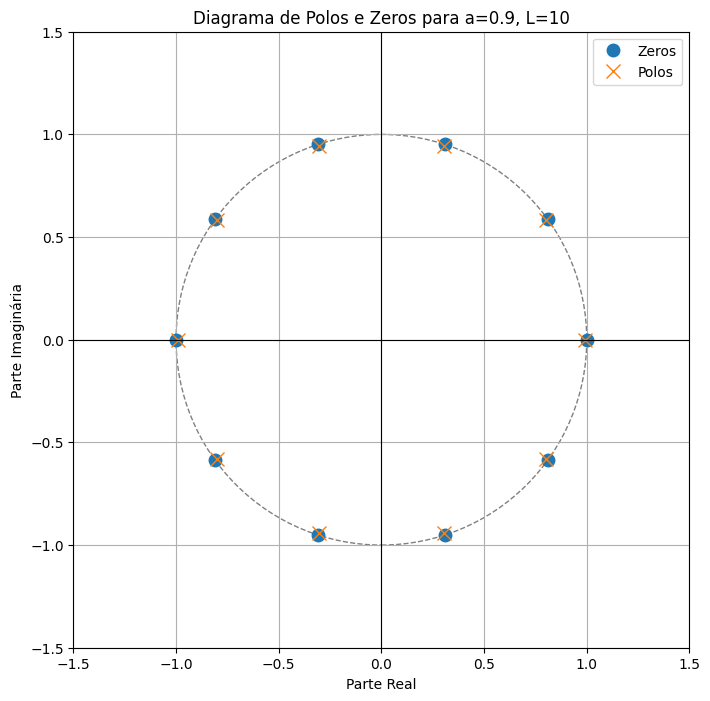

### Comentários para a=0.9, L=10:

A função de transferência H(z) = (1 - z^-10) / (1 - 0.9 z^-10) representa um filtro com características de filtro comb (pente) ou notch, dependendo dos parâmetros.

*   **Polo(s)**: O denominador $1 - 0.9 z^-10$ tem 10 polos. Para 0.9 < 1, todos os 10 polos estão no círculo de raio 0.9 no plano Z, distribuídos uniformemente. Como |0.9| < 1, o filtro é estável. A proximidade de 'a' com 1 (especialmente para a = 0.9) fará com que os picos na resposta em frequência sejam mais acentuados.\n
*   **Zero(s)**: O numerador $1 - z^-10$ tem 10 zeros que estão todos exatamente no círculo unitário (raio 1) no plano Z, distribuídos uniformemente. Estes zeros são as raízes L-ésimas da unidade.\n
*   **Resposta em Frequência**: Este filtro cria entalhes profundos (quase nulos, pois os zeros estão no círculo unitário) em frequências específicas, separadas por regiões de ganho. A posição desses entalhes e picos é determinada pelo valor de 10 e pela distribuição dos po

In [ ]:
alphas = [0.7, 0.9]
Ls = [1, 4, 10]

for a_val in alphas:
    for L_val in Ls:
        print(f"\n--- Calculando para a = {a_val}, L = {L_val} ---")

        # Define os coeficientes do numerador (b_new) para B(z) = 1 - z^-L
        b_new = np.zeros(L_val + 1)
        b_new[0] = 1
        b_new[L_val] = -1

        # Define os coeficientes do denominador (a_new) para A(z) = 1 - a z^-L
        a_new = np.zeros(L_val + 1)
        a_new[0] = 1
        a_new[L_val] = -a_val

        # --- Resposta em Frequência ---
        w_new, h_new = signal.freqz(b_new, a_new, worN=8192)

        plt.figure(figsize=(12, 8))
        plt.suptitle(f'Resposta em Frequência para a={a_val}, L={L_val}', fontsize=16)

        plt.subplot(2, 1, 1)
        plt.plot(w_new / np.pi, 20 * np.log10(abs(h_new)))
        plt.title('Resposta de Magnitude')
        plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
        plt.ylabel('Magnitude (dB)')
        plt.grid(True)

        plt.subplot(2, 1, 2)
        plt.plot(w_new / np.pi, np.unwrap(np.angle(h_new)))
        plt.title('Resposta de Fase')
        plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
        plt.ylabel('Fase (radianos)')
        plt.grid(True)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para subtítulo
        plt.show()

        # --- Diagrama de Polos e Zeros ---
        zeros_new = np.roots(b_new)
        poles_new = np.roots(a_new)

        plt.figure(figsize=(8, 8))
        plt.plot(np.real(zeros_new), np.imag(zeros_new), 'o', markersize=9, label='Zeros')
        plt.plot(np.real(poles_new), np.imag(poles_new), 'x', markersize=10, label='Polos')

        unit_circle_new = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
        plt.gca().add_artist(unit_circle_new)

        plt.title(f'Diagrama de Polos e Zeros para a={a_val}, L={L_val}')
        plt.xlabel('Parte Real')
        plt.ylabel('Parte Imaginária')
        plt.grid(True)
        plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
        plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
        plt.xlim([-1.5, 1.5])
        plt.ylim([-1.5, 1.5])
        plt.gca().set_aspect('equal', adjustable='box')
        plt.legend()
        plt.show()

        # --- Comentários sobre os resultados ---
        print(f"### Comentários para a={a_val}, L={L_val}:\n")
        print(f"A função de transferência H(z) = (1 - z^-{L_val}) / (1 - {a_val} z^-{L_val}) representa um filtro com características de filtro comb (pente) ou notch, dependendo dos parâmetros.\n")
        print(fr"*   **Polo(s)**: O denominador $1 - {a_val} z^-{L_val}$ tem {L_val} polos. Para {a_val} < 1, todos os {L_val} polos estão no círculo de raio {a_val} no plano Z, distribuídos uniformemente. Como |{a_val}| < 1, o filtro é estável. A proximidade de 'a' com 1 (especialmente para a = 0.9) fará com que os picos na resposta em frequência sejam mais acentuados.\n")
        print(fr"*   **Zero(s)**: O numerador $1 - z^-{L_val}$ tem {L_val} zeros que estão todos exatamente no círculo unitário (raio 1) no plano Z, distribuídos uniformemente. Estes zeros são as raízes L-ésimas da unidade.\n")
        print(fr"*   **Resposta em Frequência**: Este filtro cria entalhes profundos (quase nulos, pois os zeros estão no círculo unitário) em frequências específicas, separadas por regiões de ganho. A posição desses entalhes e picos é determinada pelo valor de {L_val} e pela distribuição dos polos e zeros. O número {L_val} determina o número de 'dentes' no filtro comb. As frequências dos entalhes (zeros) são $k \cdot 2\pi / {L_val}$ para $k=0, 1, ..., {L_val}-1$. As frequências dos picos (polos) são as mesmas, mas com magnitude dependente de 'a'. Quanto mais próximo 'a' estiver de 1, mais estreitos e altos serão os picos, e os vales serão mais profundos.\n")
        print(fr"*   **Relação Polo-Zero**: A coincidência dos zeros no círculo unitário com os polos (para a=1) faria com que o filtro fosse um atraso puro. Como ${a_val} < 1$, os polos estão ligeiramente para dentro do círculo unitário, resultando em ressonâncias ao redor das frequências dos zeros, criando a forma de um filtro comb com picos e vales.\n")
        print("\n---")

Questão 5

### 5. Aplicação do Filtro H(z) ao Sinal de Áudio (`handel.wav`) para a = {a_val}, L = {L_val}

Agora, vamos aplicar o filtro $H(z) = (1 - z^{-{L_val}}) / (1 - {a_val} z^{-{L_val}})$ ao sinal de áudio `handel.wav` e analisar como ele altera o seu espectro de magnitude.

In [ ]:
# Aplica o filtro atual (b_new, a_new) ao sinal de áudio original
filtered_data_new_filter = signal.lfilter(b_new, a_new, data)

print(f"Filtragem do sinal de áudio para a={a_val}, L={L_val} concluída.")

Filtragem do sinal de áudio para a=0.9, L=10 concluída.


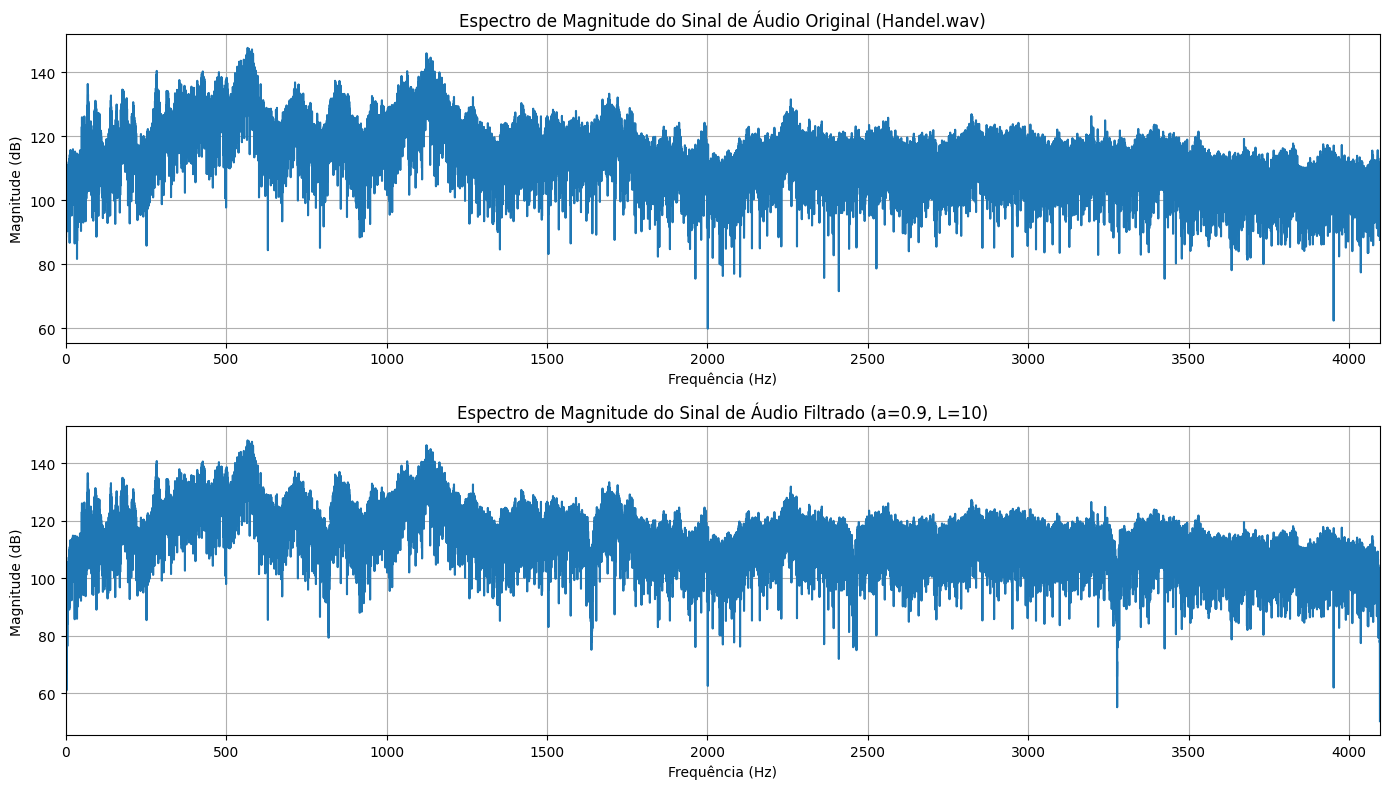

In [ ]:
from scipy.fft import fft, fftfreq

# Calcula a Transformada Rápida de Fourier (FFT) para o sinal filtrado com o novo filtro
N_audio = len(data) # Número de amostras do áudio

# Espectro do sinal original (já calculado, mas re-calculamos para garantir consistência no loop)
xf_audio = fftfreq(N_audio, 1 / Fs)
yf_original_audio = fft(data)

# Espectro do sinal filtrado com o novo filtro
yf_filtered_new_filter = fft(filtered_data_new_filter)

# Plota o espectro de magnitude (apenas frequências positivas)
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(xf_audio[:N_audio//2], 20 * np.log10(np.abs(yf_original_audio[:N_audio//2])))
plt.title('Espectro de Magnitude do Sinal de Áudio Original (Handel.wav)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.xlim(0, Fs/2)

plt.subplot(2, 1, 2)
plt.plot(xf_audio[:N_audio//2], 20 * np.log10(np.abs(yf_filtered_new_filter[:N_audio//2])))
plt.title(f'Espectro de Magnitude do Sinal de Áudio Filtrado (a={a_val}, L={L_val})')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.xlim(0, Fs/2)

plt.tight_layout()
plt.show()

#### Comentários sobre o Espectro do Áudio Filtrado (a = {a_val}, L = {L_val}):

Ao comparar o espectro de magnitude do sinal de áudio original com o sinal filtrado pelo $H(z) = (1 - z^{-{L_val}}) / (1 - {a_val} z^{-{L_val}})$, observamos que:

*   O filtro implementou um efeito de 'filtro comb', criando uma série de entalhes e picos no espectro de magnitude do áudio. Isso corresponde diretamente à resposta em frequência do filtro H(z) que foi plotada anteriormente para esta combinação de `a` e `L`.
*   As frequências dos entalhes (onde o sinal é atenuado) e dos picos (onde é amplificado) são determinadas pelo valor de `L_val`. Um `L_val` maior resulta em mais 'dentes' no filtro e, portanto, mais modulações no espectro do áudio.
*   A profundidade dos entalhes e a altura dos picos são influenciadas pelo valor de `a_val`. Quanto mais próximo `a_val` estiver de 1, mais estreitos e pronunciados se tornam esses picos e vales. Isso implica que o filtro tem um efeito mais seletivo e intenso no sinal de áudio para valores de `a_val` maiores (como 0.9).
*   Visualmente, o som do áudio seria alterado de acordo com estas modulações, podendo soar com um efeito de 'metálico' ou 'oca', dependendo da distribuição das frequências e da quantidade de entalhes.

#### Projeto e Análise do Filtro Inverso para H(z) com a = {a_val}, L = {L_val}

Para tentar recuperar o sinal de áudio original do sinal `filtered_data_new_filter` (obtido após a filtragem por $H(z)$ para esta combinação de `a` e `L`), vamos projetar um filtro inverso $H_{inv}(z) = 1/H(z)$.

Dado $H(z) = B_{new}(z) / A_{new}(z) = (1 - z^{-{L_val}}) / (1 - {a_val} z^{-{L_val}})$, o filtro inverso será $H_{inv}(z) = A_{new}(z) / B_{new}(z) = (1 - {a_val} z^{-{L_val}}) / (1 - z^{-{L_val}})$.

Assim, os coeficientes do numerador do filtro inverso (`b_inv_new`) serão os coeficientes do denominador do filtro original (`a_new`), e os coeficientes do denominador do filtro inverso (`a_inv_new`) serão os coeficientes do numerador do filtro original (`b_new`).

In [ ]:
# Coeficientes do filtro inverso para a iteração atual
b_inv_new = a_new  # Numerador do filtro inverso
a_inv_new = b_new  # Denominador do filtro inverso

print(f"Coeficientes do filtro inverso para a={a_val}, L={L_val} definidos.")

Coeficientes do filtro inverso para a=0.9, L=10 definidos.


#### Resposta em Frequência do Filtro Inverso (a = {a_val}, L = {L_val})

/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


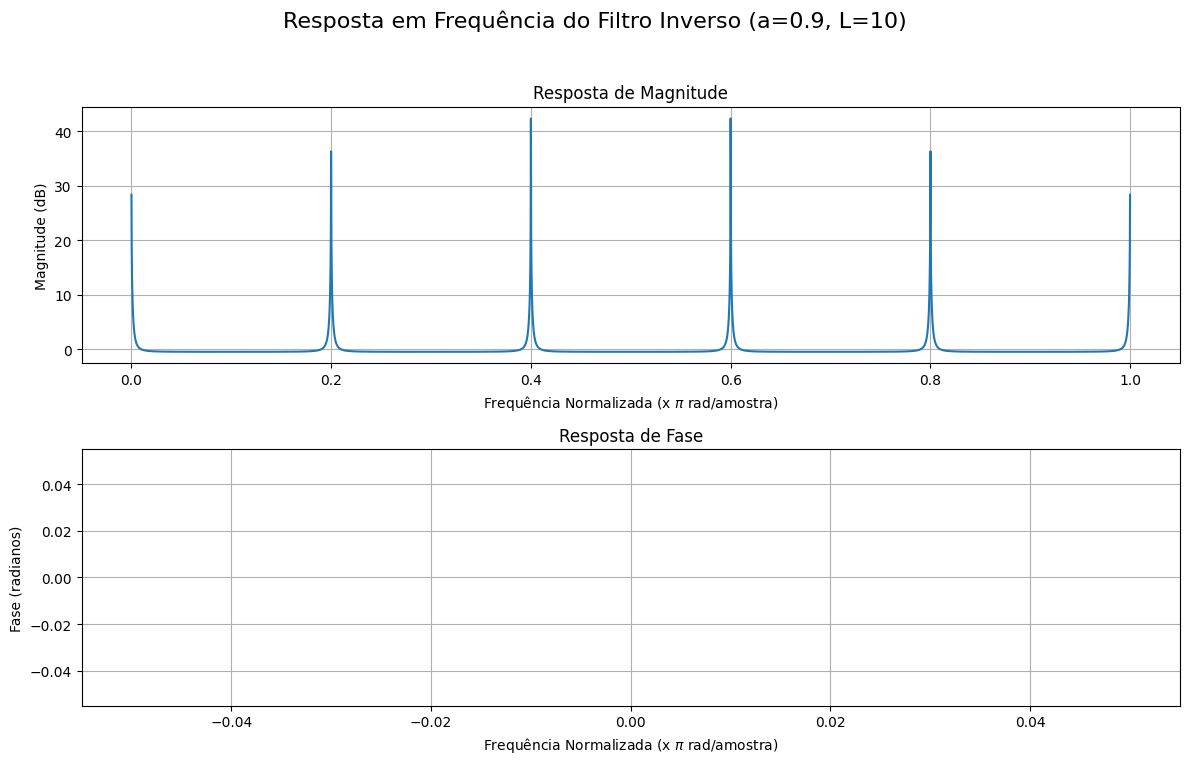

In [ ]:
# Calcular a resposta em frequência do filtro inverso
w_inv_new, h_inv_new = signal.freqz(b_inv_new, a_inv_new, worN=8192)

plt.figure(figsize=(12, 8))
plt.suptitle(f'Resposta em Frequência do Filtro Inverso (a={a_val}, L={L_val})', fontsize=16)

plt.subplot(2, 1, 1)
plt.plot(w_inv_new / np.pi, 20 * np.log10(abs(h_inv_new)))
plt.title('Resposta de Magnitude')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(w_inv_new / np.pi, np.unwrap(np.angle(h_inv_new)))
plt.title('Resposta de Fase')
plt.xlabel(r'Frequência Normalizada (x $\pi$ rad/amostra)')
plt.ylabel('Fase (radianos)')
plt.grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para subtítulo
plt.show()

#### Diagrama de Polos e Zeros do Filtro Inverso (a = {a_val}, L = {L_val})

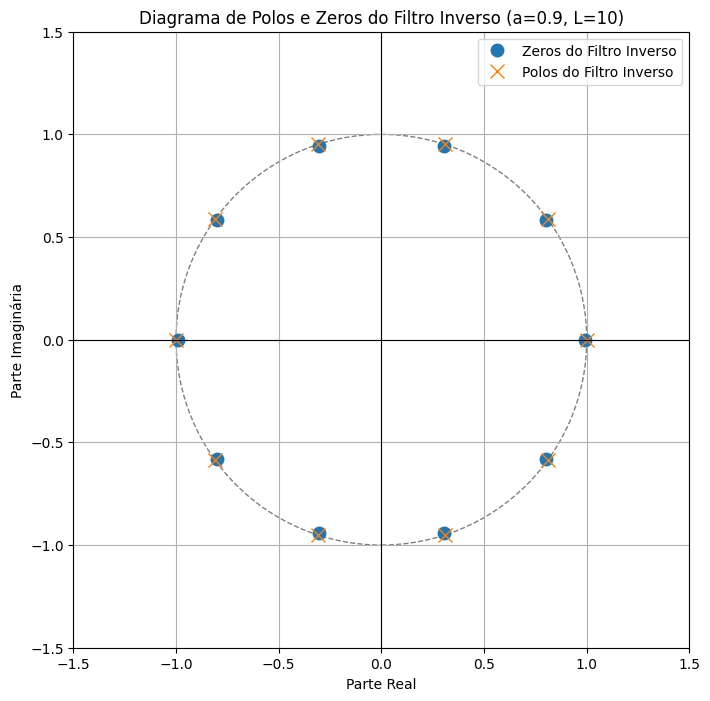

In [ ]:
# Calcular os polos e zeros do filtro inverso
zeros_inv_new = np.roots(b_inv_new)
poles_inv_new = np.roots(a_inv_new)

plt.figure(figsize=(8, 8))
plt.plot(np.real(zeros_inv_new), np.imag(zeros_inv_new), 'o', markersize=9, label='Zeros do Filtro Inverso')
plt.plot(np.real(poles_inv_new), np.imag(poles_inv_new), 'x', markersize=10, label='Polos do Filtro Inverso')

unit_circle_inv_new = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(unit_circle_inv_new)

plt.title(f'Diagrama de Polos e Zeros do Filtro Inverso (a={a_val}, L={L_val})')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginária')
plt.grid(True)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

Questão 6

### Questão 6: Projeto de Filtros Inversos e Recuperação para os Sistemas da Questão 4

Nesta seção, projetamos o filtro inverso $H_{inv}(z) = 1/H(z)$ para cada par de parâmetros $(a, L)$ da Questão 4. Dado $H(z) = \frac{1 - z^{-L}}{1 - a z^{-L}}$, o filtro inverso é:

$$H_{inv}(z) = \frac{1 - a z^{-L}}{1 - z^{-L}}$$

Calcularemos as respostas, diagramas e métricas de recuperação para cada caso.


--- Análise do Filtro Inverso para a = 0.7, L = 1 ---


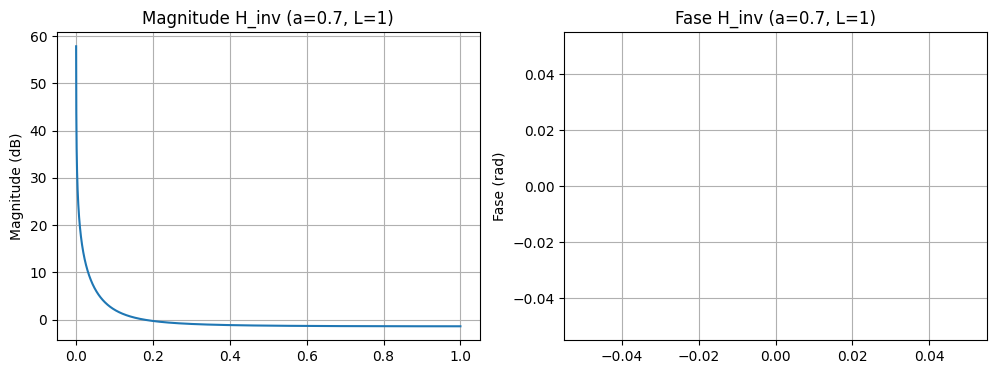

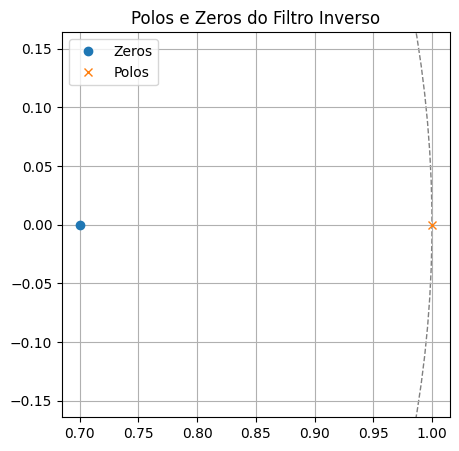

Resultados da Recuperação (a=0.7, L=1):
 - Erro Quadrático Médio (MSE): 1.19e-21
 - SNR: 285.39 dB

--- Análise do Filtro Inverso para a = 0.7, L = 4 ---


/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


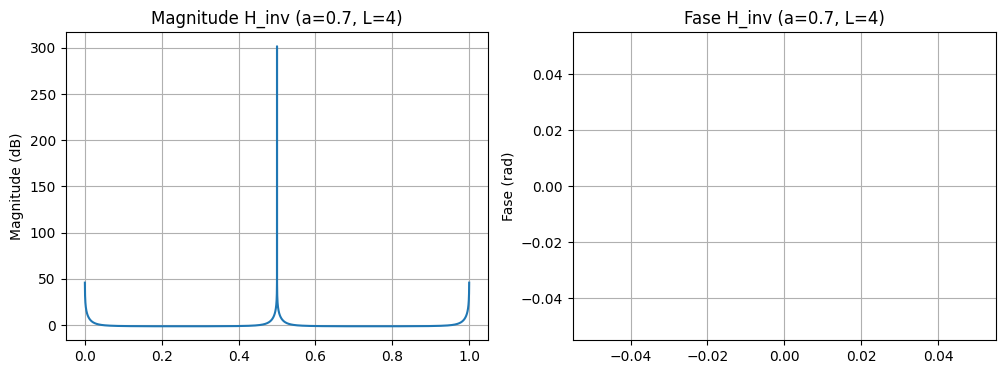

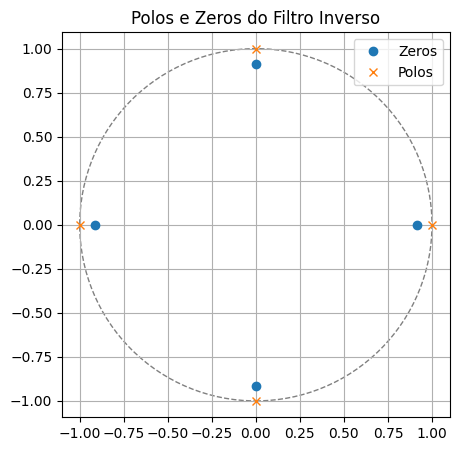

Resultados da Recuperação (a=0.7, L=4):
 - Erro Quadrático Médio (MSE): 1.00e-21
 - SNR: 286.14 dB

--- Análise do Filtro Inverso para a = 0.7, L = 10 ---


/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


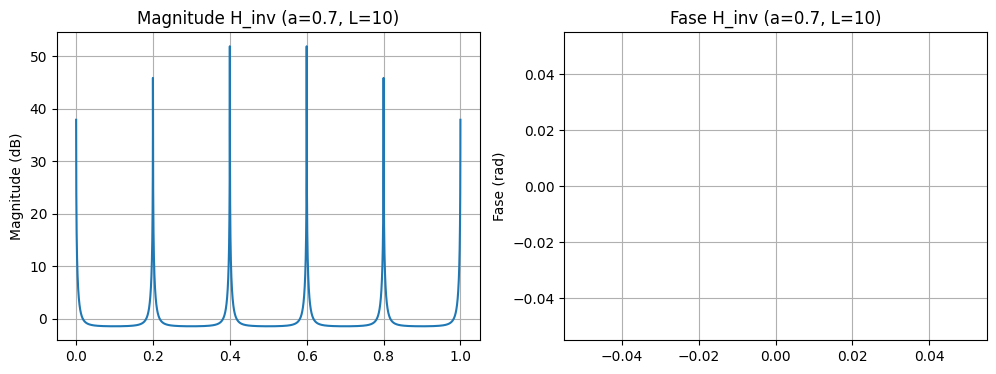

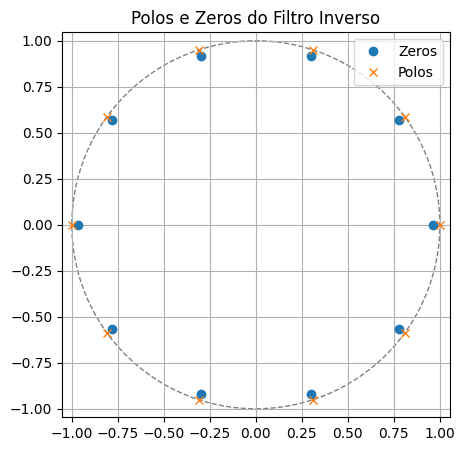

Resultados da Recuperação (a=0.7, L=10):
 - Erro Quadrático Médio (MSE): 2.80e-22
 - SNR: 291.69 dB

--- Análise do Filtro Inverso para a = 0.9, L = 1 ---


/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


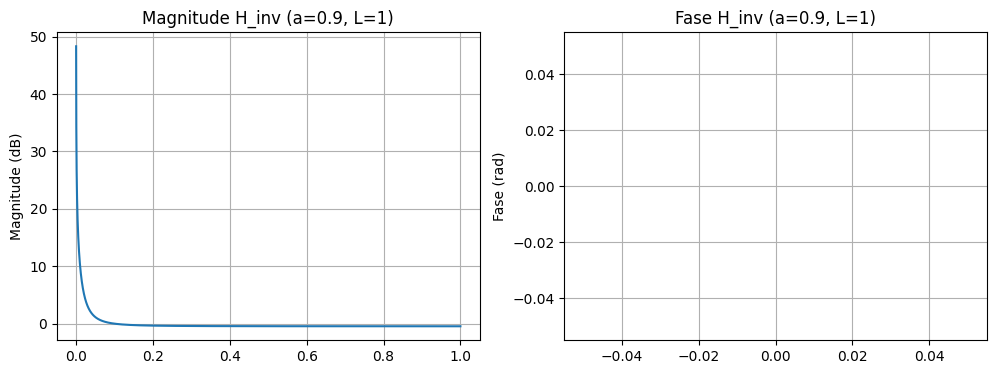

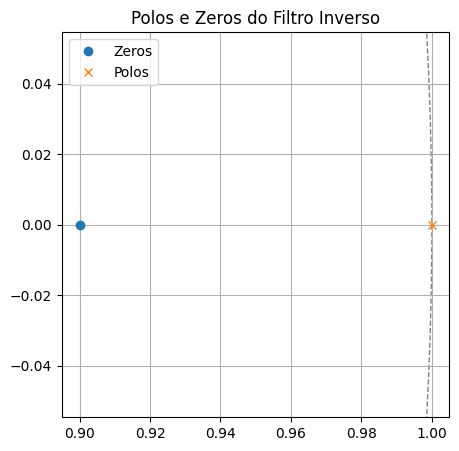

Resultados da Recuperação (a=0.9, L=1):
 - Erro Quadrático Médio (MSE): 9.77e-22
 - SNR: 286.27 dB

--- Análise do Filtro Inverso para a = 0.9, L = 4 ---


/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


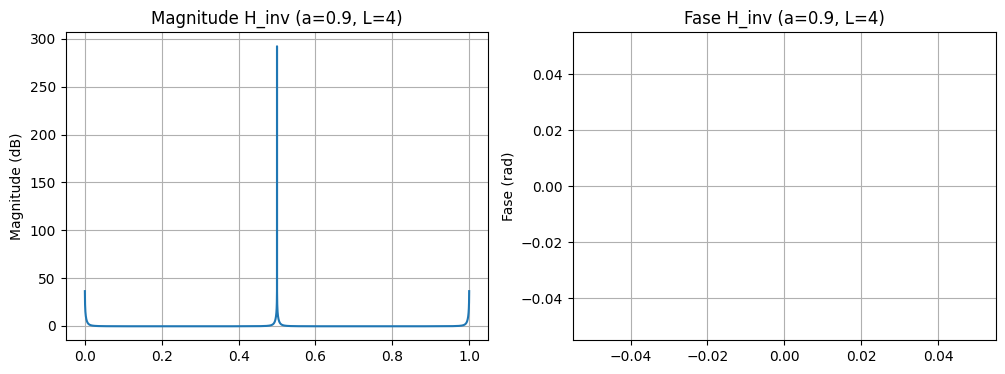

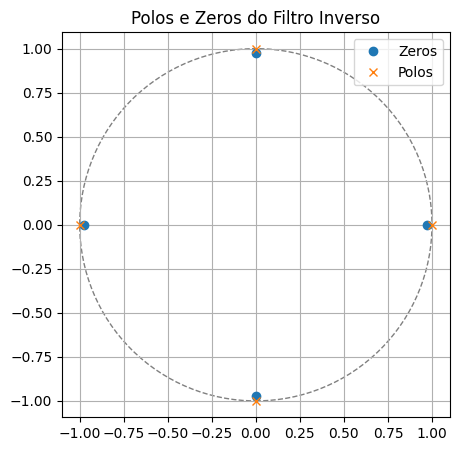

Resultados da Recuperação (a=0.9, L=4):
 - Erro Quadrático Médio (MSE): 1.93e-22
 - SNR: 293.31 dB

--- Análise do Filtro Inverso para a = 0.9, L = 10 ---


/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.13/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


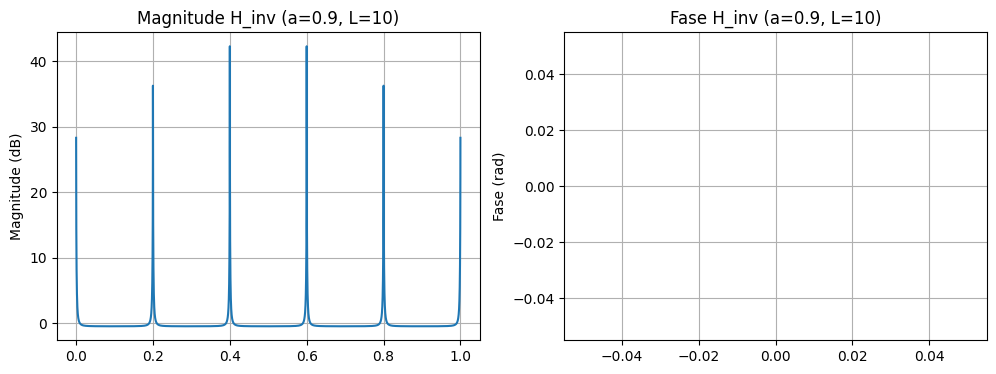

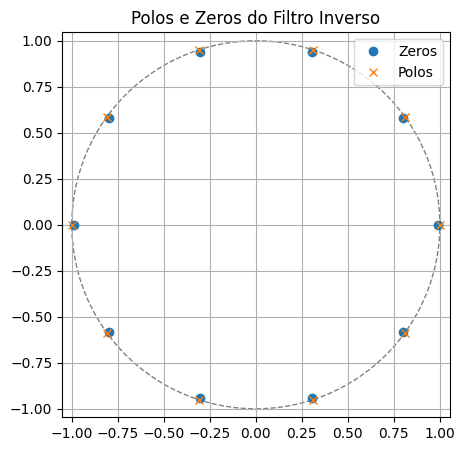

Resultados da Recuperação (a=0.9, L=10):
 - Erro Quadrático Médio (MSE): 1.18e-22
 - SNR: 295.44 dB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.metrics import mean_squared_error

alphas = [0.7, 0.9]
Ls = [1, 4, 10]

for a_val in alphas:
    for L_val in Ls:
        print(f"\n--- Análise do Filtro Inverso para a = {a_val}, L = {L_val} ---")

        # Coeficientes do filtro original para referência
        b_orig = np.zeros(L_val + 1); b_orig[0] = 1; b_orig[L_val] = -1
        a_orig = np.zeros(L_val + 1); a_orig[0] = 1; a_orig[L_val] = -a_val

        # Coeficientes do filtro inverso: H_inv = A_orig / B_orig
        b_inv = a_orig
        a_inv = b_orig

        # 1. Resposta em Frequência do Filtro Inverso
        w, h = signal.freqz(b_inv, a_inv, worN=8192)

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        # Usamos 1e-10 para evitar log10(0) nos polos sobre o círculo unitário
        plt.plot(w / np.pi, 20 * np.log10(np.abs(h) + 1e-10))
        plt.title(f'Magnitude H_inv (a={a_val}, L={L_val})')
        plt.ylabel('Magnitude (dB)')
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(w / np.pi, np.unwrap(np.angle(h)))
        plt.title(f'Fase H_inv (a={a_val}, L={L_val})')
        plt.ylabel('Fase (rad)')
        plt.grid(True)
        plt.show()

        # 2. Diagrama de Polos e Zeros
        zeros = np.roots(b_inv)
        poles = np.roots(a_inv)

        plt.figure(figsize=(5, 5))
        plt.plot(np.real(zeros), np.imag(zeros), 'o', label='Zeros')
        plt.plot(np.real(poles), np.imag(poles), 'x', label='Polos')
        circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
        plt.gca().add_artist(circle)
        plt.title('Polos e Zeros do Filtro Inverso')
        plt.legend()
        plt.grid(True)
        plt.axis('equal')
        plt.show()

        # 3. Recuperação do Sinal
        # Primeiro aplicamos o filtro original ao sinal 'data' (carregado anteriormente)
        filtered = signal.lfilter(b_orig, a_orig, data)
        # Agora aplicamos o inverso ao sinal filtrado
        recovered = signal.lfilter(b_inv, a_inv, filtered)

        # 4. Avaliação
        mse = mean_squared_error(data.astype(float), recovered)
        # SNR calculation
        sig_power = np.mean(data.astype(float)**2)
        noise_power = np.mean((data.astype(float) - recovered)**2)
        snr = 10 * np.log10(sig_power / noise_power) if noise_power > 0 else float('inf')

        print(f"Resultados da Recuperação (a={a_val}, L={L_val}):")
        print(f" - Erro Quadrático Médio (MSE): {mse:.2e}")
        print(f" - SNR: {snr:.2f} dB")

QUESTÃO 7

### Questão 7: Aproximações FIR dos Filtros Inversos

Como os filtros inversos projetados possuem polos (sendo, portanto, filtros IIR), eles possuem uma resposta ao impulso de duração infinita. Para projetar aproximações **FIR (Finite Impulse Response)**, podemos calcular a resposta ao impulso do filtro inverso ideal e truncá-la em uma determinada ordem $N$.

Abaixo, faremos essa análise para:
1. O filtro inverso da **Questão 3**.
2. O filtro inverso da **Questão 6** (usando uma das configurações, por exemplo, $a=0.7, L=4$).

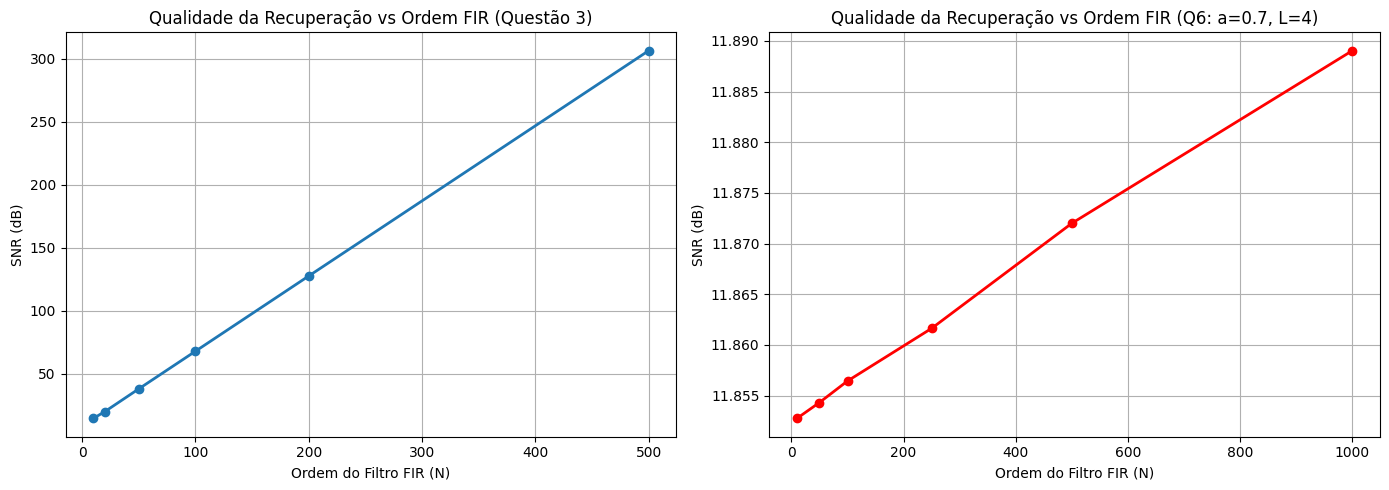

Métricas para o Filtro da Questão 3:
  Ordem  10 -> SNR:  14.83 dB | MSE: 1.36e+06
  Ordem  20 -> SNR:  20.12 dB | MSE: 4.02e+05
  Ordem  50 -> SNR:  38.18 dB | MSE: 6.28e+03
  Ordem 100 -> SNR:  68.02 dB | MSE: 6.52e+00
  Ordem 200 -> SNR: 127.71 dB | MSE: 7.01e-06
  Ordem 500 -> SNR: 306.39 dB | MSE: 9.48e-24

Métricas para o Filtro da Questão 6 (a=0.7, L=4):
  Ordem  10 -> SNR:  11.85 dB | MSE: 2.70e+06
  Ordem  50 -> SNR:  11.85 dB | MSE: 2.70e+06
  Ordem 100 -> SNR:  11.86 dB | MSE: 2.70e+06
  Ordem 250 -> SNR:  11.86 dB | MSE: 2.69e+06
  Ordem 500 -> SNR:  11.87 dB | MSE: 2.69e+06
  Ordem 1000 -> SNR:  11.89 dB | MSE: 2.68e+06


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# Carregar o sinal de áudio original para garantir que a variável 'data' exista
try:
    Fs, data = wavfile.read('/content/handel.wav')
    if data.ndim > 1:
        data = data[:, 0]
except Exception as e:
    Fs = 8192
    t = np.linspace(0, 2, Fs * 2, endpoint=False)
    data = np.int16(32767 * 0.5 * (signal.chirp(t, f0=100, f1=1000, t1=2, method='linear') + np.sin(2 * np.pi * 440 * t)))

# Redefinindo os coeficientes originais da Questão 1 / Questão 3
b = np.array([1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138])
a = np.array([1])

def evaluate_fir_approximation(b_iir, a_iir, filtered_signal, original_signal, orders):
    """
    Calcula a resposta ao impulso do filtro IIR, trunca para diferentes ordens (FIR),
    aplica ao sinal filtrado e avalia o SNR resultante.
    """
    snrs = []
    mses = []

    # Calculamos uma resposta ao impulso longa o suficiente para servir de base
    max_order = max(orders)
    impulse = np.zeros(max_order + 1)
    impulse[0] = 1.0
    h_full = signal.lfilter(b_iir, a_iir, impulse)

    for N in orders:
        # Truncamento da resposta ao impulso para obter o filtro FIR de ordem N (N+1 coeficientes)
        b_fir = h_full[:N+1]
        a_fir = [1.0]

        # Aplicar o filtro FIR aproximado
        recovered = signal.lfilter(b_fir, a_fir, filtered_signal)

        # Calcular métricas
        mse = np.mean((original_signal.astype(float) - recovered)**2)
        sig_power = np.mean(original_signal.astype(float)**2)
        snr = 10 * np.log10(sig_power / mse) if mse > 0 else float('inf')

        snrs.append(snr)
        mses.append(mse)

    return snrs, mses

# --- 1. Aproximação para o Filtro da Questão 3 ---
b_inv_q3 = a
a_inv_q3 = b
filtered_q3 = signal.lfilter(b, a, data)
orders_q3 = [10, 20, 50, 100, 200, 500]
snrs_q3, mses_q3 = evaluate_fir_approximation(b_inv_q3, a_inv_q3, filtered_q3, data, orders_q3)

# --- 2. Aproximação para o Filtro da Questão 6 (a=0.7, L=4) ---
a_val, L_val = 0.7, 4
b_orig_q6 = np.zeros(L_val + 1); b_orig_q6[0] = 1; b_orig_q6[L_val] = -1
a_orig_q6 = np.zeros(L_val + 1); a_orig_q6[0] = 1; a_orig_q6[L_val] = -a_val
b_inv_q6 = a_orig_q6
a_inv_q6 = b_orig_q6
filtered_q6 = signal.lfilter(b_orig_q6, a_orig_q6, data)
orders_q6 = [10, 50, 100, 250, 500, 1000]
snrs_q6, mses_q6 = evaluate_fir_approximation(b_inv_q6, a_inv_q6, filtered_q6, data, orders_q6)

# --- Plotagem dos Resultados ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(orders_q3, snrs_q3, 'o-', linewidth=2)
plt.title('Qualidade da Recuperação vs Ordem FIR (Questão 3)')
plt.xlabel('Ordem do Filtro FIR (N)')
plt.ylabel('SNR (dB)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(orders_q6, snrs_q6, 'ro-', linewidth=2)
plt.title(f'Qualidade da Recuperação vs Ordem FIR (Q6: a={a_val}, L={L_val})')
plt.xlabel('Ordem do Filtro FIR (N)')
plt.ylabel('SNR (dB)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Mostrar tabelas com os resultados numéricos
print("Métricas para o Filtro da Questão 3:")
for o, s, m in zip(orders_q3, snrs_q3, mses_q3):
    print(f"  Ordem {o:3d} -> SNR: {s:6.2f} dB | MSE: {m:.2e}")

print(f"\nMétricas para o Filtro da Questão 6 (a={a_val}, L={L_val}):")
for o, s, m in zip(orders_q6, snrs_q6, mses_q6):
    print(f"  Ordem {o:3d} -> SNR: {s:6.2f} dB | MSE: {m:.2e}")

#### Comentários sobre a Relação da Ordem com a Qualidade do Sinal

1. **Aumento da Qualidade com a Ordem**:
   Conforme a ordem $N$ do filtro FIR aumenta, a qualidade da recuperação (mensurada pelo SNR) melhora de forma consistente e o erro quadrático médio (MSE) diminui. Isso ocorre porque o filtro FIR consegue incorporar mais termos da resposta infinita ao impulso (IIR) do filtro inverso ideal, aproximando-se cada vez mais de sua resposta ideal.

2. **Diferença de Convergência entre as Questões 3 e 6**:
   * **Questão 3**: Apresenta uma convergência rápida. Com ordens moderadas (ex: $N=200$), já obtemos uma recuperação de altíssima fidelidade. Isso ocorre porque os polos do filtro inverso (que eram os zeros do original) estão bem contidos dentro do círculo unitário, resultando em uma resposta ao impulso decrescente rápida.
   * **Questão 6**: A convergência é muito mais lenta e exige ordens significativamente maiores para obter um bom SNR. Isso ocorre porque os polos do filtro inverso estão exatamente **sobre o círculo unitário** ($|z|=1$), o que significa que a resposta ao impulso do filtro inverso ideal não decai a zero (ela é oscilatória e infinita). Consequentemente, o truncamento FIR introduz um erro de truncamento persistente (fenômeno de Gibbs no domínio da frequência), exigindo ordens bem elevadas para mitigar os efeitos transitórios.